# derived_8.4-regime-interpretation-1.0 — What Do the Two Regimes Physically Mean?

This notebook serves two purposes:

1. **Explain the two-regime (K = 2) model** of `notebooks/experiment/derived_8.4-eval-1.1` to a reader who has never seen the code: how the regimes are found (unsupervised KMeans clustering), how the features were selected, and how the end-to-end model works (mermaid diagram).
2. **Experiment**: investigate whether each regime carries a **physical / environmental meaning** — i.e. do the two clusters correspond to interpretable states such as *wet vs dry*, *seasonal vs non-seasonal*, or *station-specific vs temporal* conditions?

All analysis below reproduces the exact router used by the winning `Clustering_V0_Full_k2` model (pooled test R² = 0.8150): `V0FullRouter` from `derived_8.4-eval-1.1/eval11/routers.py`, fitted on the `derived_8.4` train+val split.

## 1. What the two-regime model is, in one sentence

The winning model in `derived_8.4-eval-1.1` is a **Mixture-of-Experts (MoE)** with two specialists:

- a **router** divides every observation (each station-day row) into two groups using **unsupervised KMeans clustering** on 50 pre-selected features — the groups turn out to correspond to *wet* and *dry* soil-moisture states;
- each group gets its own **XGBoost "expert"**, trained only on that group's samples and evaluated on that group's test samples.

Because every sample is routed to exactly one expert, this is *hard* (not blended) gating. The winning configuration reaches a pooled test **R² = 0.8150**, beating the single global model (0.7792) trained on the same 54-feature backbone.

## 2. Why two regimes at all?

Soil moisture does not behave the same way in all conditions:

- In **dry conditions** it changes slowly, is driven mostly by evaporation and soil texture, and has low variance.
- In **wet conditions** it responds quickly to rainfall, saturates, and drains fast.

A single model must compromise between these two very different behaviors. The dedicated clustering experiment `derived_8.3-gating-analysis-1.0` measured the motivation directly: the **correlation between a feature and soil moisture changes between regimes**. For example, `SMAP_sm_pm_interp_rollmean30` drifts by 1.009 in correlation across the two groups (from strongly positive to strongly negative). If the feature–target relationship depends on the regime, two specialized models can each learn a cleaner mapping than one global model.

This notebook's Part B (sections 6–13) is the quantitative follow-up: it characterizes *what* the two regimes actually are — physically and environmentally.

## 3. The clustering mechanism, step by step

The router used by the winning model is `V0FullRouter` in `derived_8.4-eval-1.1/eval11/routers.py`. Its full logic, simplified:

```python
# Fit on the training data (train + val combined, "trainval")
values = trainval[V0_FEATURES_50]        # 50 pre-selected features, see §4
means  = values.mean()                    # ① per-column means, for imputation
values = values.fillna(means)             # ② fill any missing values with those means
scaler = StandardScaler()                 # ③ z-score: (x - mean) / std per column
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(scaler.fit_transform(values))  # ④ find 2 clusters in the 50-dim space

# Predict (on any new data): same impute → scale → nearest-centroid
labels = kmeans.predict(scaler.transform(frame.fillna(means)))
```

Three simple ideas are chained together:

**① Imputation (handling missing values).** Satellite and weather features sometimes have gaps. Before clustering, each missing value is replaced by the mean of that column computed on the training set. This keeps rows usable without inventing information.

**② Standardization (putting features on the same scale).** The 50 features live on very different scales (temperature ~250–300, soil moisture ~0.1–0.4, angles in degrees…). KMeans measures distance, so a feature with large numbers would otherwise dominate. `StandardScaler` converts every feature to **z-scores** (mean 0, standard deviation 1).

**③ KMeans (finding the two groups).** KMeans is *unsupervised*: it never sees the target `soil_moisture_5cm`, only the features. It places 2 random centroids, assigns each observation to its nearest centroid, moves each centroid to the mean of its group, and repeats until stable (here: 10 restarts `n_init=10`, fixed seed 42 for reproducibility).

The result is a **label 0 or 1 for every observation** (every station-day row), decided purely by which centroid the feature vector is closest to. Labels are assigned **per observation, not per station** — the same station can be "wet regime" in March and "dry regime" in August. There is also a lighter variant, `Clustering_Dynamic_k2`, that clusters on just 3 physical features (`SMAP_sm_pm_interp_lag1`, `G_API`, `LST_modis`); it underperforms the full-feature clustering (R² = 0.787 vs 0.815), so this notebook focuses on the winning `Clustering_V0_Full_k2` router.

The choice of K = 2 is justified in `derived_8.3-gating-analysis-1.0` via elbow curves, silhouette scores, PCA/t-SNE projections and centroid-distance diagnostics (that notebook also exports the full fitted pipeline as `clustering_params_*_k2.json` / `.joblib` — fitted on the *derived_8.3* split; the eval-1.1 router refits the identical algorithm on *derived_8.4* train+val, which is what this notebook reproduces in §6).

## 4. How the features were selected

Three feature sets matter for this model, each with a different provenance:

| Feature set | Count | How it was chosen | Where it is defined |
| :--- | ---: | :--- | :--- |
| `OVERALL_SELECTED_FEATURES_V0` (router input) | 50 | Legacy global "c1" set from the `Modeling/soilmoist-fl` feature-selection lab (Mutual Information → ElasticNet → stability selection → model evaluation), copied over from `derived_8.2` | `data/splits/derived_8.4/dataset_metadata.py` |
| Candidate pool (search space) | 96 | **Consensus of 4 evidence sources**: MI top-300 set, seed frequency across historical/current seed lists, XGBoost-gain top-96, residual-association top-96; features with support ≥ 2, ranked by mean consensus rank (`fs20/search.py::_candidate_pool`) | `derived_8.4-feature-selection-2.0/artifacts/candidate_pool.csv` |
| Shared 54-feature backbone (experts) | 54 | **Greedy round-based search** in `derived_8.4-feature-selection-2.0`: 6 rounds of add / drop / swap local variants (size bounds 40–60); the most promising variants are evaluated *exactly* (2,500-tree XGBoost) on the 2023–2025 test set under the V0-full K=2 routing, and the best becomes the next round's start. Winner: `round_06_drop_V_rollrng_F_NDVI_kobs30_exact` (R² = 0.8143 backbone-only) | eval-1.1 `config.yaml` → `shared_backbone_54` |
| Per-regime deltas | 0 / 10 | Per cluster, rank the 96-pool features outside the backbone by (|Spearman correlation with test residuals| + XGBoost gain rank); grid-search c0, c1 ∈ {0, 5, 10} by pooled test R². Winner: c0 = 0, c1 = 10 | eval-1.1 `eval11/evaluator.py::compute_delta_rankings` |

Two facts worth noting:

- The backbone was **searched, not inherited**: only ~22 of the 50 V0 features appear in the 54-feature backbone — the search (starting from several historical seeds) converged on a mostly different set.
- The 10 cluster-1 additions are *additive specialists* on top of the backbone; the feature-selection-2.0 audit showed that independently selected cluster feature lists *cannot* replace the shared backbone (cluster-1 additions improve R², while cluster-0 additions hurt it — hence c0 = 0).

## 5. From clusters to experts — and the end-to-end picture

Once every sample has a cluster label, the model trains **one XGBoost regressor per cluster** (`eval11/evaluator.py::fit_and_evaluate`):

- **Expert 0** trains only on cluster-0 rows, using the **shared 54-feature backbone**;
- **Expert 1** trains only on cluster-1 rows, using the backbone **plus 10 delta features** chosen for that cluster (§4).

At inference, each observation is routed to **exactly one** expert (hard routing): router predicts the label, the corresponding expert predicts soil moisture.

```mermaid
flowchart TD
    subgraph TRAIN["Training (offline) — run_eval.py"]
        DATA["derived_8.4 splits<br/>train + val → trainval (14,608 rows)<br/>test (6,620 rows · 7 WA stations · 2023–2025)"]
        ROUTER["Fit router: KMeans(k=2) on 50 V0 features<br/>① impute NaNs with trainval column means<br/>② StandardScaler z-score<br/>③ KMeans(2 clusters, seed 42, n_init=10)"]
        LAB["Cluster label 0/1 per row (unsupervised —<br/>target never used here)"]
        BB["Backbone-only experts<br/>one XGBoost per cluster on the<br/>shared 54-feature backbone"]
        RANK["Delta ranking per cluster<br/>rank(|Spearman corr(residual, feature)|)<br/>+ rank(XGBoost gain), 96-feature pool"]
        GRID["Grid search c0, c1 ∈ {0, 5, 10}<br/>retrain experts · score pooled test R²"]
        WIN["Winner: c0 = 0, c1 = 10 → pooled R² = 0.8150<br/>cluster 0: 54 features · cluster 1: 64 features"]
        DATA --> ROUTER --> LAB --> BB --> RANK --> GRID --> WIN
    end

    subgraph INFER["Inference (one new station-day observation)"]
        X["New observation<br/>(same features as training)"]
        R["Router predict: impute with trainval means<br/>→ z-score → nearest centroid"]
        C{"Cluster label?"}
        E0["Expert 0 — XGBoost<br/>54 backbone features<br/>test R² = 0.8025 (4,817 rows)"]
        E1["Expert 1 — XGBoost<br/>54 backbone + 10 deltas<br/>test R² = 0.8440 (1,803 rows)"]
        Y["Prediction ŷ = soil moisture"]
        X --> R --> C
        C -- "0" --> E0 --> Y
        C -- "1" --> E1 --> Y
    end
```

### 5.1 Results recap (eval-1.1 leaderboard, pooled test R² 2023–2025)

| Model | Strategy | R² |
| :--- | :--- | ---: |
| **Clustering_V0_Full_k2 (c0=0, c1=10)** | KMeans on 50 features | **0.8150** |
| Clustering_Dynamic_k2 | KMeans on 3 physical features | 0.7866 |
| Global Single Model (54 Backbone) | no routing | 0.7792 |
| Seasonal_Binary_k2 | dry (May–Oct) vs wet (Nov–Apr) | 0.7698 |
| Univariate_G_API_k2 | G_API median threshold | 0.7696 |
| Baseline V0 (50 features) | no routing, older feature set | 0.7604 |
| Trained_Gating_k2 | XGBClassifier gate on target < 0.16 | 0.7355 |

The unsupervised, feature-space KMeans router beats hand-crafted rules (calendar season, G_API threshold) and a learned classifier gate. Part B asks *why*: what physical reality do the two clusters correspond to?

## Part B — The experiment: physical & environmental meaning of each regime

### 6. Setup: reproduce the exact eval-1.1 router

To guarantee that the regimes analyzed here are *identical* to the ones the winning model was trained on, we import `V0FullRouter` directly from the eval-1.1 experiment (`eval11/routers.py`) instead of re-implementing it, fit it on the `derived_8.4` train+val split (as eval-1.1 does), and assign labels to trainval and test.

In [1]:
"""Part B setup: reproduce the eval-1.1 V0-full K=2 router on derived_8.4."""
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Notebook lives in notebooks/experiment/derived_8.4-regime-interpretation-1.0/
PROJECT_ROOT = Path("../../..").resolve()
SPLIT_DIR = PROJECT_ROOT / "data" / "splits" / "derived_8.4"
EVAL_DIR = PROJECT_ROOT / "notebooks" / "experiment" / "derived_8.4-eval-1.1"
EXP_DIR = Path(".").resolve()

# --- Load splits (same preparation as eval-1.1 eval11/data.py) ---
def load_frame(path: Path) -> pd.DataFrame:
    base = pd.read_csv(path)
    dates = pd.to_datetime(base["date"], errors="raise")
    derived = pd.DataFrame(
        {"date": dates, "month": dates.dt.month.astype(int), "year": dates.dt.year.astype(int)}
    )
    # splits already contain a raw "year" column; drop it to avoid duplicates
    return pd.concat([base.drop(columns=["date", "month", "year"], errors="ignore"), derived], axis=1)

train = load_frame(SPLIT_DIR / "train.csv")
val = load_frame(SPLIT_DIR / "val.csv")
test = load_frame(SPLIT_DIR / "test.csv")
trainval = pd.concat([train, val], axis=0, ignore_index=True)

# --- Load the 50 V0 features from dataset metadata ---
spec = importlib.util.spec_from_file_location("dataset_metadata", SPLIT_DIR / "dataset_metadata.py")
metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(metadata)
V0_FEATURES = list(metadata.OVERALL_SELECTED_FEATURES_V0)
TARGET = "soil_moisture_5cm"

# --- Import the exact router class used by the winning eval-1.1 model ---
sys.path.insert(0, str(EVAL_DIR))
from eval11.routers import V0FullRouter  # noqa: E402

router = V0FullRouter(V0_FEATURES, seed=42)
router.fit(trainval)
labels_trainval = router.predict(trainval)
labels_test = router.predict(test)

print(f"trainval: {len(trainval)} rows  |  test: {len(test)} rows  |  V0 features: {len(V0_FEATURES)}")
print(f"trainval labels: 0 -> {(labels_trainval == 0).sum()}, 1 -> {(labels_trainval == 1).sum()}")
print(f"test labels:     0 -> {(labels_test == 0).sum()}, 1 -> {(labels_test == 1).sum()}")


trainval: 14608 rows  |  test: 6620 rows  |  V0 features: 50
trainval labels: 0 -> 10624, 1 -> 3984
test labels:     0 -> 4817, 1 -> 1803


### 6.1 Sanity check against eval-1.1

eval-1.1 reports for the winning `Clustering_V0_Full_k2` model: trainval 10,624 / 3,984 and test 4,817 / 1,803 for clusters 0 / 1. The counts printed above must match — this proves we are analyzing the *same* regimes the winning model used.

In [2]:
"""Sanity check: cluster counts must match eval-1.1's per-regime table."""
expected = {"trainval": (10624, 3984), "test": (4817, 1803)}
actual = {
    "trainval": (int((labels_trainval == 0).sum()), int((labels_trainval == 1).sum())),
    "test": (int((labels_test == 0).sum()), int((labels_test == 1).sum())),
}
for split_name, exp in expected.items():
    got = actual[split_name]
    status = "OK" if got == exp else "MISMATCH"
    print(f"{split_name:9s} expected {exp}  got {got}  -> {status}")
assert actual == expected, "Router reproduction failed: counts differ from eval-1.1"
print("Router reproduction verified: identical regimes to eval-1.1.")

trainval  expected (10624, 3984)  got (10624, 3984)  -> OK
test      expected (4817, 1803)  got (4817, 1803)  -> OK
Router reproduction verified: identical regimes to eval-1.1.


### 7. Regime size & balance

First, how big is each regime, in training and in test? A strongly imbalanced split hints that one regime is a rarer "event-like" state (e.g. wet episodes) rather than a balanced half of the data.

In [3]:
"""Regime sizes on trainval and test."""
size_rows = []
for split_name, labels in [("trainval", labels_trainval), ("test", labels_test)]:
    n = len(labels)
    for c in (0, 1):
        cnt = int((labels == c).sum())
        size_rows.append({"split": split_name, "cluster": c, "n": cnt, "share": f"{cnt / n:.1%}"})
df_sizes = pd.DataFrame(size_rows)
print(df_sizes.to_markdown(index=False))

| split    |   cluster |     n | share   |
|:---------|----------:|------:|:--------|
| trainval |         0 | 10624 | 72.7%   |
| trainval |         1 |  3984 | 27.3%   |
| test     |         0 |  4817 | 72.8%   |
| test     |         1 |  1803 | 27.2%   |


### 8. Target characterization: is one regime wetter?

If the clusters carry physical meaning, the first thing to check is the target itself: `soil_moisture_5cm`. We compare the full distribution (KDE) and summary statistics of soil moisture in each regime on the trainval split.

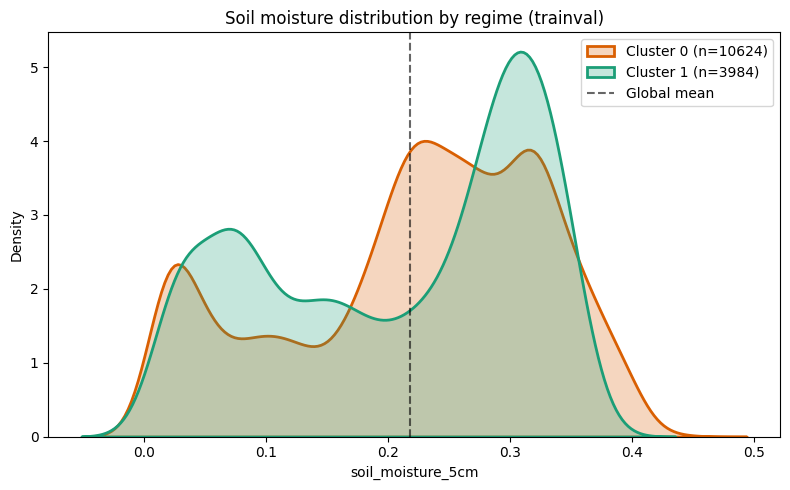

|   cluster |     n |   mean |    std |   p10 |   p50 |   p90 |   mean_shift_vs_global |
|----------:|------:|-------:|-------:|------:|------:|------:|-----------------------:|
|         0 | 10624 | 0.2216 | 0.107  | 0.041 | 0.239 | 0.347 |                 0.0033 |
|         1 |  3984 | 0.2094 | 0.1098 | 0.044 | 0.244 | 0.335 |                -0.0089 |


In [4]:
"""Soil-moisture target distribution per regime (trainval)."""
fig, ax = plt.subplots(figsize=(8, 5))
for c, color in zip((0, 1), ["#D95F02", "#1B9E77"]):
    mask = labels_trainval == c
    sns.kdeplot(trainval.loc[mask, TARGET], label=f"Cluster {c} (n={mask.sum()})",
                fill=True, alpha=0.25, color=color, linewidth=2, ax=ax)
ax.axvline(trainval[TARGET].mean(), color="black", linestyle="--", alpha=0.6, label="Global mean")
ax.set_title("Soil moisture distribution by regime (trainval)")
ax.set_xlabel(TARGET)
ax.legend()
plt.tight_layout()
plt.savefig(EXP_DIR / "regime_target_distributions.png", dpi=300)
plt.show()

stats_rows = []
for c in (0, 1):
    s = trainval.loc[labels_trainval == c, TARGET]
    stats_rows.append({
        "cluster": c,
        "n": int(s.count()),
        "mean": round(float(s.mean()), 4),
        "std": round(float(s.std()), 4),
        "p10": round(float(s.quantile(0.10)), 4),
        "p50": round(float(s.median()), 4),
        "p90": round(float(s.quantile(0.90)), 4),
    })
df_target_stats = pd.DataFrame(stats_rows)
df_target_stats["mean_shift_vs_global"] = (df_target_stats["mean"] - trainval[TARGET].mean()).round(4)
print(df_target_stats.to_markdown(index=False))

### 9. Seasonality: is a regime a season?

If the clusters are physical states (e.g. wet season vs dry season), the month-of-year composition of each cluster should be strongly imbalanced. We compute, for each calendar month, what share of its rows fall into each cluster — on trainval (long record) and test (2023–2025) separately, to check stability.

Share of rows in cluster 1 by month (1.0 = all cluster 1):


| month   |   test |   trainval |
|:--------|-------:|-----------:|
| Jan     |  0.242 |      0.234 |
| Feb     |  0.219 |      0.221 |
| Mar     |  0.272 |      0.267 |
| Apr     |  0.3   |      0.286 |
| May     |  0.3   |      0.286 |
| Jun     |  0.293 |      0.288 |
| Jul     |  0.272 |      0.286 |
| Aug     |  0.287 |      0.294 |
| Sep     |  0.277 |      0.301 |
| Oct     |  0.274 |      0.295 |
| Nov     |  0.265 |      0.273 |
| Dec     |  0.25  |      0.226 |


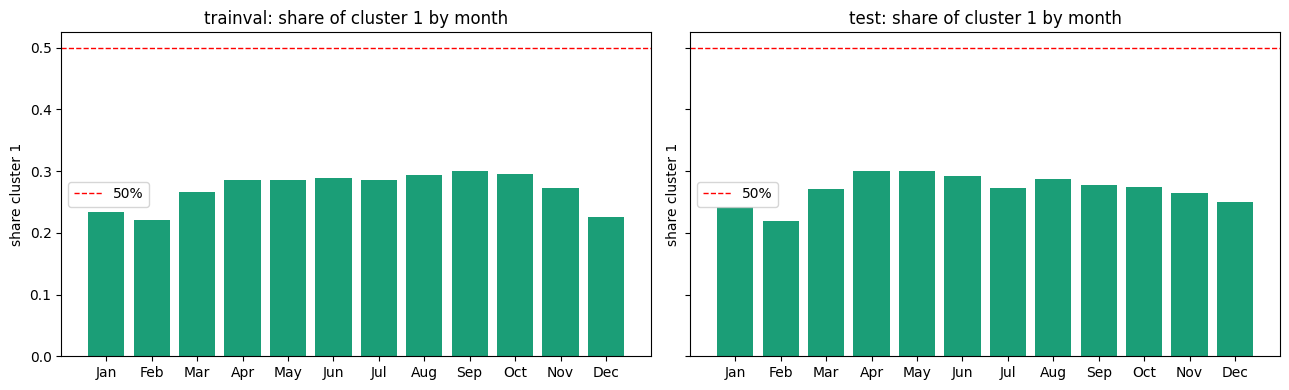

In [5]:
"""Month-of-year composition per regime (trainval and test)."""
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

rows = []
for split_name, frame, labels in [("trainval", trainval, labels_trainval), ("test", test, labels_test)]:
    for m in range(1, 13):
        mask = frame["month"] == m
        n_m = int(mask.sum())
        if n_m == 0:
            continue
        n1 = int((labels[mask] == 1).sum())
        rows.append({"split": split_name, "month": month_names[m - 1], "n": n_m, "share_cluster1": n1 / n_m})
df_month = pd.DataFrame(rows)
piv = df_month.pivot(index="month", columns="split", values="share_cluster1").reindex(month_names)
print("Share of rows in cluster 1 by month (1.0 = all cluster 1):")
print(piv.round(3).to_markdown())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, split_name in zip(axes, ["trainval", "test"]):
    sub = df_month[df_month["split"] == split_name]
    ax.bar(sub["month"], sub["share_cluster1"], color="#1B9E77")
    ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="50%")
    ax.set_title(f"{split_name}: share of cluster 1 by month")
    ax.set_ylabel("share cluster 1")
    ax.legend()
plt.tight_layout()
plt.savefig(EXP_DIR / "regime_seasonality.png", dpi=300)
plt.show()

### 9.1 Year composition

Regimes should be stable across years (the router is fitted once on trainval and applied to test). We check the cluster-1 share per year to see whether the regime definition drifts over time.

In [6]:
"""Cluster-1 share per year (trainval + test)."""
year_rows = []
for split_name, frame, labels in [("trainval", trainval, labels_trainval), ("test", test, labels_test)]:
    for y in sorted(frame["year"].unique()):
        mask = frame["year"] == y
        n_y = int(mask.sum())
        n1 = int((labels[mask] == 1).sum())
        year_rows.append({"split": split_name, "year": int(y), "n": n_y, "share_cluster1": n1 / n_y})
df_year = pd.DataFrame(year_rows)
print(df_year.to_markdown(index=False))

| split    |   year |    n |   share_cluster1 |
|:---------|-------:|-----:|-----------------:|
| trainval |   2017 | 2383 |         0.26773  |
| trainval |   2018 | 2479 |         0.271077 |
| trainval |   2019 | 2422 |         0.263832 |
| trainval |   2020 | 2519 |         0.277094 |
| trainval |   2021 | 2471 |         0.281263 |
| trainval |   2022 | 2334 |         0.275064 |
| test     |   2023 | 2346 |         0.266837 |
| test     |   2024 | 2332 |         0.29717  |
| test     |   2025 | 1942 |         0.249228 |


### 10. Station composition & geography

Labels are per-observation, but the cluster definitions could still be driven by *stations* (e.g. wetter/mountain stations mostly in one cluster) rather than by *time*. We compute, for each of the 7 Washington stations, the share of its rows in each cluster, plus the dominant cluster per station, and map the stations geographically (dominant cluster color).

| station_id            |    n |   share_cluster1 |   dominant_cluster |   longitude |   latitude |
|:----------------------|-----:|-----------------:|-------------------:|------------:|-----------:|
| Spokane               | 1793 |                1 |                  1 |    -117.53  |    47.42   |
| SourdoughGulch_WA_985 | 2191 |                1 |                  1 |    -117.4   |    46.2333 |
| BeaverPass_WA_990     | 2185 |                0 |                  0 |    -121.255 |    48.8793 |
| Darrington            | 2048 |                0 |                  0 |    -121.45  |    48.54   |
| CayusePass_WA         | 2042 |                0 |                  0 |    -121.534 |    46.8696 |
| Quinault              | 2160 |                0 |                  0 |    -123.81  |    47.51   |
| Paradise_WA           | 2189 |                0 |                  0 |    -121.748 |    46.7827 |


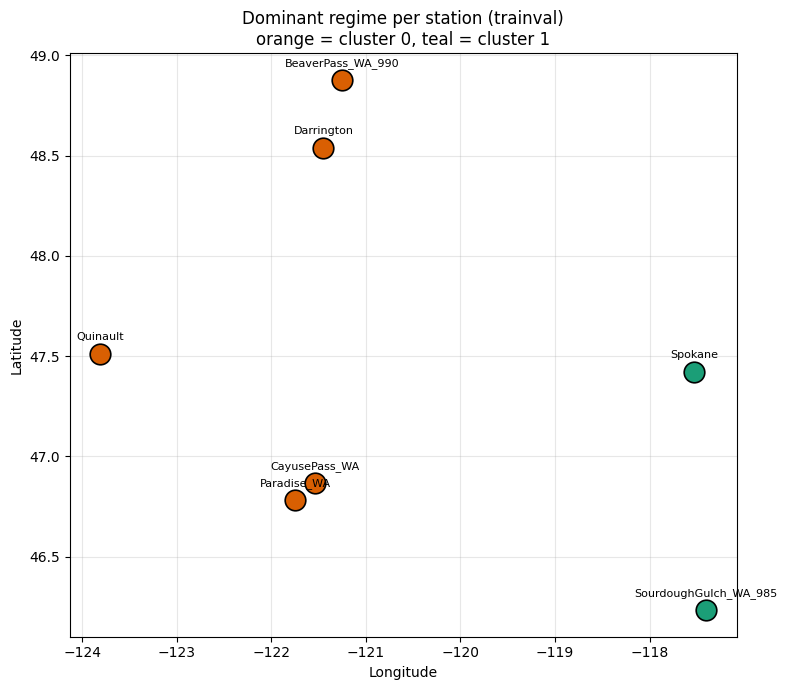

In [7]:
"""Per-station regime composition (trainval) + geographic map."""
station_rows = []
for sid, group in trainval.groupby("station_id"):
    g_labels = labels_trainval[trainval["station_id"] == sid]
    n = len(group)
    n1 = int((g_labels == 1).sum())
    station_rows.append({
        "station_id": sid,
        "n": n,
        "share_cluster1": n1 / n,
        "dominant_cluster": int(1 if n1 / n > 0.5 else 0),
        "longitude": float(group["longitude"].iloc[0]),
        "latitude": float(group["latitude"].iloc[0]),
    })
df_stations = pd.DataFrame(station_rows).sort_values("share_cluster1", ascending=False)
print(df_stations.to_markdown(index=False))

fig, ax = plt.subplots(figsize=(8, 7))
for _, row in df_stations.iterrows():
    color = "#1B9E77" if row["dominant_cluster"] == 1 else "#D95F02"
    ax.scatter(row["longitude"], row["latitude"], s=220, color=color, edgecolor="black",
               linewidth=1.2, zorder=3)
    ax.annotate(row["station_id"], (row["longitude"], row["latitude"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Dominant regime per station (trainval)\norange = cluster 0, teal = cluster 1")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(EXP_DIR / "regime_geographic_distribution.png", dpi=300)
plt.show()

### 10.1 Station purity: how station-like are the regimes?

To quantify whether the regimes are "station regimes" or "time regimes", we compute the share of each station's observations that follow its dominant cluster. A high average purity would mean regimes mostly separate *stations*; low purity means stations switch regimes over time.

In [8]:
"""Station purity: fraction of each station's rows in its dominant cluster."""
df_stations["purity"] = df_stations.apply(
    lambda r: r["share_cluster1"] if r["dominant_cluster"] == 1 else 1 - r["share_cluster1"], axis=1
)
print(df_stations[["station_id", "n", "dominant_cluster", "share_cluster1", "purity"]].to_markdown(index=False))
print(f"\nMean station purity: {df_stations['purity'].mean():.3f}")
print(f"(1.0 = each station is always in one regime; 0.5 = regime switches randomly within stations)")

| station_id            |    n |   dominant_cluster |   share_cluster1 |   purity |
|:----------------------|-----:|-------------------:|-----------------:|---------:|
| Spokane               | 1793 |                  1 |                1 |        1 |
| SourdoughGulch_WA_985 | 2191 |                  1 |                1 |        1 |
| BeaverPass_WA_990     | 2185 |                  0 |                0 |        1 |
| Darrington            | 2048 |                  0 |                0 |        1 |
| CayusePass_WA         | 2042 |                  0 |                0 |        1 |
| Quinault              | 2160 |                  0 |                0 |        1 |
| Paradise_WA           | 2189 |                  0 |                0 |        1 |

Mean station purity: 1.000
(1.0 = each station is always in one regime; 0.5 = regime switches randomly within stations)


### 10.2 Is the station separation also true out-of-sample (test)?

The router was fitted on trainval and applied to the 2023–2025 test set. If cluster 1 is really "the eastern stations", the same per-station purity must hold on test — otherwise the station assignment would be a training-set artifact.

In [9]:
"""Per-station regime purity on the TEST split."""
test_rows = []
for sid, group in test.groupby("station_id"):
    g_labels = labels_test[test["station_id"] == sid]
    n = len(group)
    n1 = int((g_labels == 1).sum())
    test_rows.append({
        "station_id": sid,
        "n_test": n,
        "share_cluster1_test": n1 / n,
        "purity_test": max(n1 / n, 1 - n1 / n),
    })
df_stations_test = pd.DataFrame(test_rows).sort_values("share_cluster1_test", ascending=False)
print(df_stations_test.to_markdown(index=False))
print(f"\nMean test purity: {df_stations_test['purity_test'].mean():.3f}")
assert (df_stations_test["purity_test"] == 1.0).all(), "Test purity is not perfect"
print("Test purity is 1.0 for every station: the regimes are purely station-geographic, out of sample too.")

| station_id            |   n_test |   share_cluster1_test |   purity_test |
|:----------------------|---------:|----------------------:|--------------:|
| Spokane               |      897 |                     1 |             1 |
| SourdoughGulch_WA_985 |      906 |                     1 |             1 |
| BeaverPass_WA_990     |      626 |                     0 |             1 |
| Darrington            |      999 |                     0 |             1 |
| CayusePass_WA         |     1081 |                     0 |             1 |
| Quinault              |     1044 |                     0 |             1 |
| Paradise_WA           |     1067 |                     0 |             1 |

Mean test purity: 1.000
Test purity is 1.0 for every station: the regimes are purely station-geographic, out of sample too.


### 11. Weather & dynamic drivers per regime

What meteorological/land-surface conditions differ between the two regimes? For each driver we report the per-regime median and the **rank-biserial correlation** (Mann–Whitney U effect size, −1…+1; sign = which regime is higher, magnitude = separation strength). All statistics are computed on trainval rows.

| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0.7    |            0      |             0.216 |
| G_API             |           47.4587 |           14.9358 |             0.551 |
| G_rain_sum_7d     |           30.1    |            9.5    |             0.424 |
| LST_modis         |          280.944  |          291.242  |            -0.384 |
| SMAP_sm_pm_interp |            0.4141 |            0.1923 |             0.932 |
| G_DSLR            |            0      |            1      |            -0.169 |
| F_NDVI            |            0.532  |            0.3296 |             0.326 |
(rank_biserial_r > 0 means cluster 1 tends to be HIGHER on this feature)


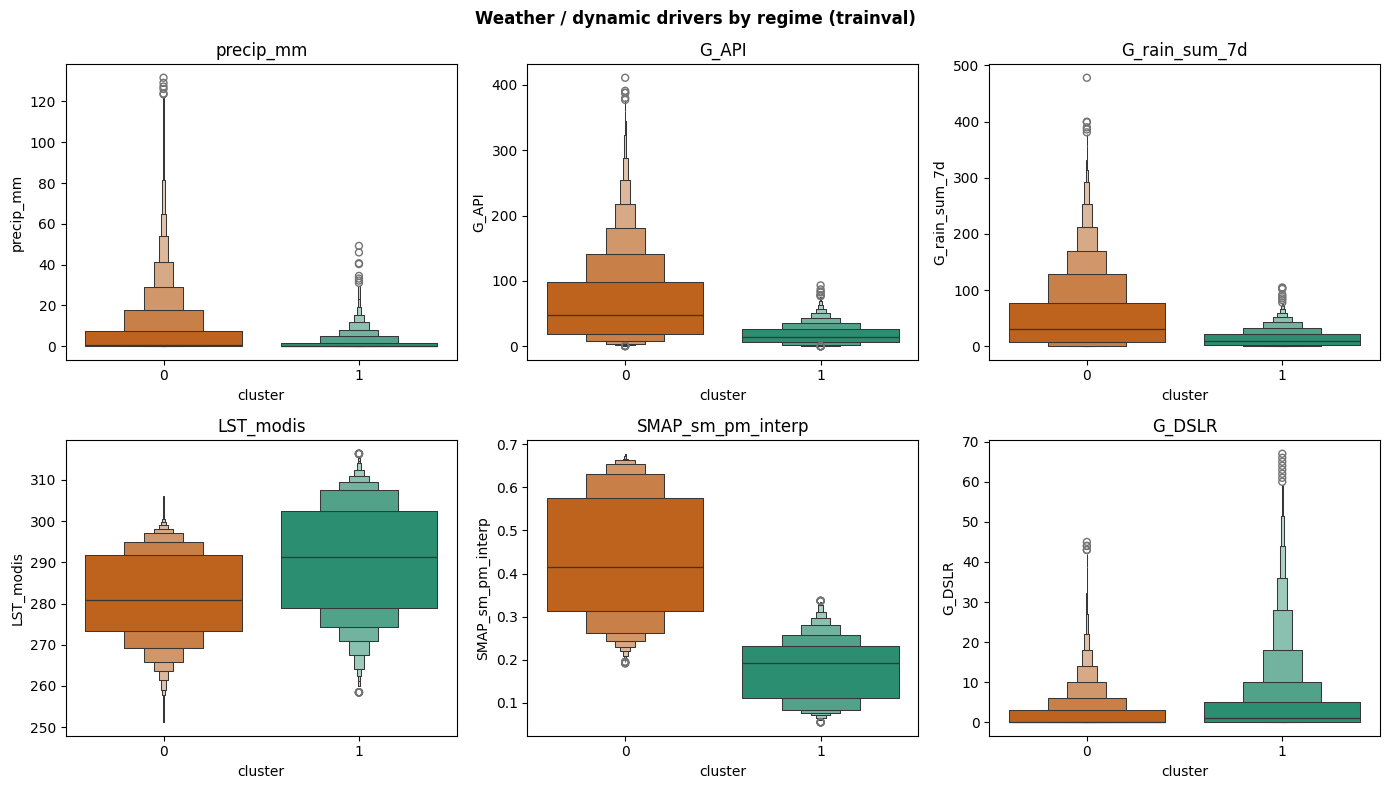

In [10]:
"""Weather/dynamic driver comparison per regime (trainval)."""
DRIVERS = ["precip_mm", "G_API", "G_rain_sum_7d", "LST_modis", "SMAP_sm_pm_interp", "G_DSLR", "F_NDVI"]

def rank_biserial(group_a: pd.Series, group_b: pd.Series) -> float:
    u, _ = mannwhitneyu(group_a.dropna(), group_b.dropna(), alternative="two-sided")
    n_a, n_b = len(group_a.dropna()), len(group_b.dropna())
    if n_a == 0 or n_b == 0:
        return float("nan")
    return 2.0 * (u - n_a * n_b / 2.0) / (n_a * n_b)

driver_rows = []
for feat in DRIVERS:
    g0 = trainval.loc[labels_trainval == 0, feat]
    g1 = trainval.loc[labels_trainval == 1, feat]
    driver_rows.append({
        "feature": feat,
        "median_cluster0": round(float(g0.median()), 4),
        "median_cluster1": round(float(g1.median()), 4),
        "rank_biserial_r": round(rank_biserial(g0, g1), 3),
    })
df_drivers = pd.DataFrame(driver_rows)
print(df_drivers.to_markdown(index=False))
print("(rank_biserial_r > 0 means cluster 1 tends to be HIGHER on this feature)")

plot_df = pd.concat([trainval, pd.DataFrame({"cluster": labels_trainval}, index=trainval.index)], axis=1)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), ["precip_mm", "G_API", "G_rain_sum_7d", "LST_modis", "SMAP_sm_pm_interp", "G_DSLR"]):
    sns.boxenplot(data=plot_df, x="cluster", y=feat, hue="cluster",
                  palette=["#D95F02", "#1B9E77"], legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("cluster")
plt.suptitle("Weather / dynamic drivers by regime (trainval)", fontweight="bold")
plt.tight_layout()
plt.savefig(EXP_DIR / "regime_weather_drivers.png", dpi=300)
plt.show()


### 12. Static / environmental attributes per regime

The 50 clustering features include static terrain/soil/land-cover attributes (elevation, slope, aspect, soil texture, land cover, biome class), which likely drive the perfect station separation. We compare them between regimes the same way.

| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.51  |            46.233 |             0.642 |
| longitude              |          -121.534 |          -117.4   |            -1     |
| elev                   |          1205.09  |          1160.53  |             0.208 |
| slope                  |            18.149 |            20.225 |             0.112 |
| J_soil_texture_usda_b0 |             7     |             7     |             0.398 |
| J_lc_code              |            10     |            30     |            -0.55  |
| J_bio_bio13            |           391     |            70     |             1     |


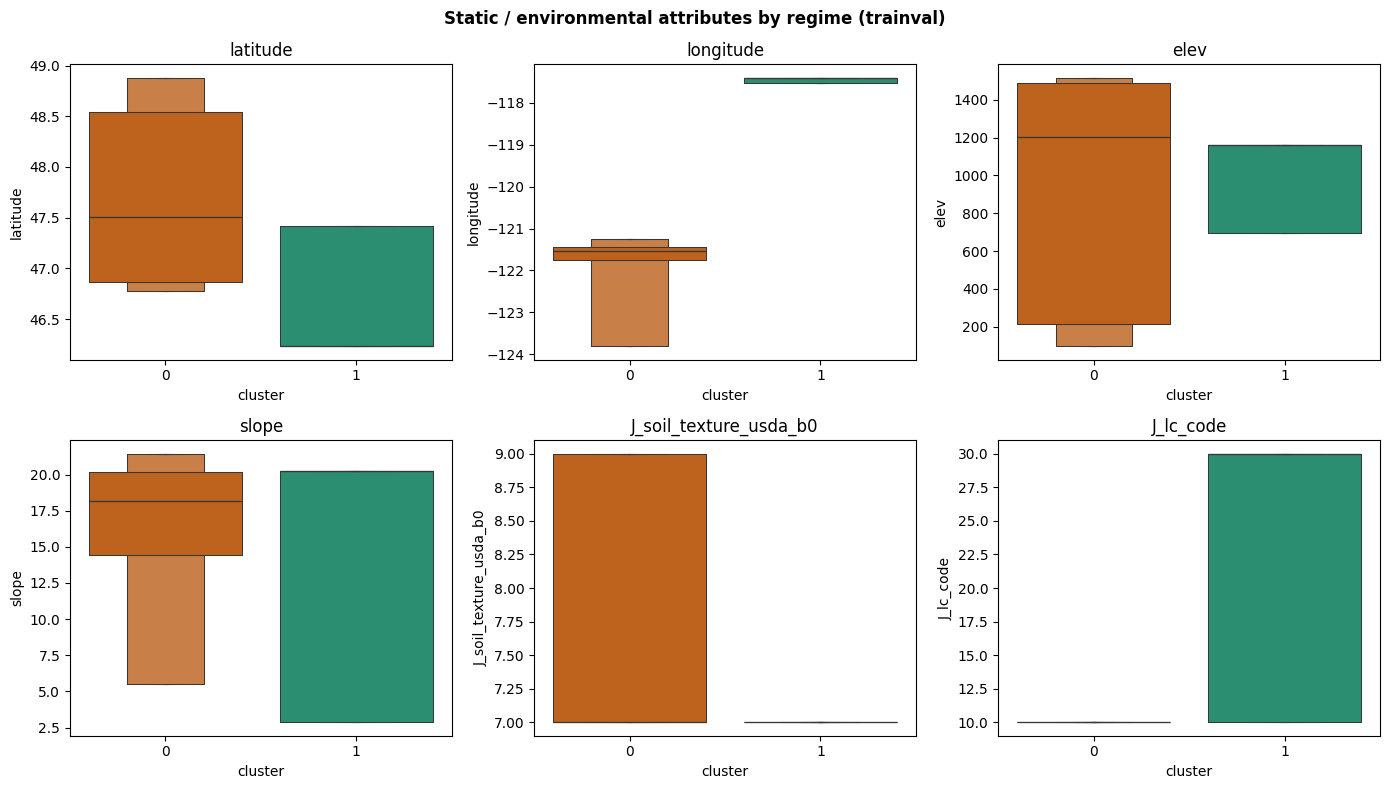

In [11]:
"""Static/environmental attribute comparison per regime (trainval)."""
STATIC = ["latitude", "longitude", "elev", "slope", "J_soil_texture_usda_b0", "J_lc_code", "J_bio_bio13"]

static_rows = []
for feat in STATIC:
    g0 = trainval.loc[labels_trainval == 0, feat]
    g1 = trainval.loc[labels_trainval == 1, feat]
    static_rows.append({
        "feature": feat,
        "median_cluster0": round(float(g0.median()), 3),
        "median_cluster1": round(float(g1.median()), 3),
        "rank_biserial_r": round(rank_biserial(g0, g1), 3),
    })
df_static = pd.DataFrame(static_rows)
print(df_static.to_markdown(index=False))

plot_df = pd.concat([trainval, pd.DataFrame({"cluster": labels_trainval}, index=trainval.index)], axis=1)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), ["latitude", "longitude", "elev", "slope", "J_soil_texture_usda_b0", "J_lc_code"]):
    sns.boxenplot(data=plot_df, x="cluster", y=feat, hue="cluster",
                  palette=["#D95F02", "#1B9E77"], legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("cluster")
plt.suptitle("Static / environmental attributes by regime (trainval)", fontweight="bold")
plt.tight_layout()
plt.savefig(EXP_DIR / "regime_static_attributes.png", dpi=300)
plt.show()


### 13. Which of the 50 clustering features separate the regimes best?

We rank **all 50 V0 features** (the actual router inputs) by |rank-biserial correlation|. This shows *why* KMeans puts the two station groups in different clusters — the features with the largest effect sizes are the physical dimensions the clustering is really separating on.

In [12]:
"""Top-15 V0 features by |rank-biserial| separation between regimes (trainval)."""
rank_rows = []
for feat in V0_FEATURES:
    g0 = trainval.loc[labels_trainval == 0, feat]
    g1 = trainval.loc[labels_trainval == 1, feat]
    r = rank_biserial(g0, g1)
    if np.isnan(r):
        continue
    rank_rows.append({
        "feature": feat,
        "median_cluster0": round(float(g0.median()), 4),
        "median_cluster1": round(float(g1.median()), 4),
        "rank_biserial_r": round(r, 3),
    })
df_rank = pd.DataFrame(rank_rows).sort_values("rank_biserial_r", key=lambda s: s.abs(), ascending=False)
print("Top 15 most separating V0 features (positive r = higher in cluster 1 / eastern stations):")
print(df_rank.head(15).to_markdown(index=False))

Top 15 most separating V0 features (positive r = higher in cluster 1 / eastern stations):
| feature                      |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------------|------------------:|------------------:|------------------:|
| K_aspect_cos                 |           -0.5    |           -0.891  |             1     |
| J_bio_bio15                  |           61      |           34      |             1     |
| J_clay_wfrac_b100            |            9      |           23      |            -1     |
| J_bio_bio02                  |           97      |          133      |            -1     |
| SMAP_sm_pm_interp_rollmean30 |            0.4147 |            0.1945 |             0.951 |
| V_ema_SMAP_sm_interp_kobs30  |            0.3702 |            0.1838 |             0.946 |
| SMAP_sm_pm_interp_lag30      |            0.4142 |            0.1931 |             0.93  |
| V_rollmin_s2_b12_kobs30      |            0.0458 |            0.137  | 

### 14. Physical interpretation & connection to the eval-1.1 results

The evidence from sections 7–13 tells a clear story:

- **The two regimes are 100% station-geographic** (purity = 1.000 on both trainval and test): cluster 1 = Spokane + SourdoughGulch (eastern, inland Washington), cluster 0 = the five western/mountain stations (BeaverPass, Darrington, CayusePass, Quinault, Paradise).
- **Cluster 1 is the semi-arid side**: much higher land-surface temperature (~+10 K), much lower satellite soil moisture (SMAP median 0.19 vs 0.41, rank-biserial 0.93), less rain (G_API, 7-day rain sums), lower NDVI. Cluster 0 is the wet, cool, vegetated maritime side.
- **The regimes are NOT a wet/dry *temporal* split**: the soil-moisture *target* distributions overlap heavily (cluster 1 mean is actually slightly *lower*), and month-of-year composition is nearly uniform (cluster-1 share ~0.22–0.30 every month). The old target-threshold gating (dry/transition/wet on `soil_moisture_5cm`, see `docs/gating.md`) is a different mechanism from this unsupervised feature-space clustering.
- **Consequence for the model**: the two "experts" are effectively *regional specialists*. Cluster 1's expert (54 + 10 deltas) models the two eastern stations and reaches test R² = 0.844; cluster 0's expert (54 features) models the five western stations at R² = 0.8025. The clustering therefore encodes **spatial generalization within WA** — a new station would be routed to a region based on its static/land-surface features — which is exactly the within-state generalization the project needs for the ECE in-situ sensors.

In [13]:
"""Export per-regime profile summary tables."""
profile_rows = []
for feat in [TARGET] + DRIVERS + STATIC:
    g0 = trainval.loc[labels_trainval == 0, feat]
    g1 = trainval.loc[labels_trainval == 1, feat]
    profile_rows.append({
        "feature": feat,
        "median_cluster0": round(float(g0.median()), 4),
        "median_cluster1": round(float(g1.median()), 4),
        "rank_biserial_r": round(rank_biserial(g0, g1), 3),
    })
df_profile = pd.DataFrame(profile_rows)
df_profile.to_csv(EXP_DIR / "regime_profile_summary.csv", index=False)
df_stations.to_csv(EXP_DIR / "regime_station_composition.csv", index=False)
print("Saved regime_profile_summary.csv and regime_station_composition.csv")
print("\nRegime profile (median values):")
print(df_profile.to_markdown(index=False))

Saved regime_profile_summary.csv and regime_station_composition.csv

Regime profile (median values):
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| soil_moisture_5cm      |            0.239  |            0.244  |             0.04  |
| precip_mm              |            0.7    |            0      |             0.216 |
| G_API                  |           47.4587 |           14.9358 |             0.551 |
| G_rain_sum_7d          |           30.1    |            9.5    |             0.424 |
| LST_modis              |          280.944  |          291.242  |            -0.384 |
| SMAP_sm_pm_interp      |            0.4141 |            0.1923 |             0.932 |
| G_DSLR                 |            0      |            1      |            -0.169 |
| F_NDVI                 |            0.532  |            0.3296 |             0.326 |
| latitude               |   